# Week 2
## 1.Work flow Continue

In [1]:
#2026-5-14
# This block is to import the result and workflow last time.
import numpy as np
import pandas as pd
from scipy.fftpack import dct, idct
from pathlib import Path
import matplotlib.pyplot as plt
from kilosort.io import load_ops

SAVE_PATH = Path('F:\\ACADEMIC') / '.test_data' / 'ZFM-02370_mini.imec0.ap.short.bin'

n_chan = 385          # channel number
N = 267 # Neuron Number
dtype = 'int16'

# Load the saved Sorting results from the local drive.
results_dir = SAVE_PATH.parent / 'kilosort4'
ops = load_ops(results_dir / 'ops.npy')
camps = pd.read_csv(results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values
contam_pct = pd.read_csv(results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values
chan_map =  np.load(results_dir / 'channel_map.npy')
templates =  np.load(results_dir / 'templates.npy')
chan_best = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best = chan_map[chan_best]
amplitudes = np.load(results_dir / 'amplitudes.npy')
st = np.load(results_dir / 'spike_times.npy')
clu = np.load(results_dir / 'spike_clusters.npy')

fs = ops['fs']
firing_rates = np.unique(clu, return_counts=True)[1] * fs / st.max()
dshift = ops['dshift']

In [2]:
# Get the spike time for each neuron.
unique_clusters = np.unique(clu)

spikes_by_cluster = {}

for cluster_id in unique_clusters:
    times = st[clu == cluster_id] / fs  # fs is the sampling frequency。
    spikes_by_cluster[cluster_id] = times

for cluster_id in unique_clusters[:5]:
    print(f"Cluster {cluster_id}: {len(spikes_by_cluster[cluster_id])} spikes")

Cluster 0: 748 spikes
Cluster 1: 605 spikes
Cluster 2: 1175 spikes
Cluster 3: 1351 spikes
Cluster 4: 1464 spikes


## 2. DCT for original

In [3]:
def compress_signal_dct(signal, keep_ratio=0.1): #signal: input singal, e.g. a part of data in a certain channel.
    
    n = len(signal)
    dct_coeffs = dct(signal, norm='ortho')
    
    cutoff = int(n * keep_ratio) # the number of remaining parameters
    compressed_coeffs = np.zeros(n)
    compressed_coeffs[:cutoff] = dct_coeffs[:cutoff]
    
    # inverse DCT to recover the signal
    reconstructed_signal = idct(compressed_coeffs, norm='ortho')
    
    return reconstructed_signal, compressed_coeffs

In [5]:
np.memmap?

Init signature:
np.memmap(
    filename,
    dtype=<class 'numpy.uint8'>,
    mode='r+',
    offset=0,
    shape=None,
    order='C',
)
Docstring:     
Create a memory-map to an array stored in a *binary* file on disk.

Memory-mapped files are used for accessing small segments of large files
on disk, without reading the entire file into memory.  NumPy's
memmap's are array-like objects.  This differs from Python's ``mmap``
module, which uses file-like objects.

This subclass of ndarray has some unpleasant interactions with
some operations, because it doesn't quite fit properly as a subclass.
An alternative to using this subclass is to create the ``mmap``
object yourself, then create an ndarray with ndarray.__new__ directly,
passing the object created in its 'buffer=' parameter.

This class may at some point be turned into a factory function
which returns a view into an mmap buffer.

Flush the memmap instance to write the changes to the file. Currently there
is no API to close the underl

In [4]:
# Use memmap method to read the portion of data when accessing a specific slice to save memory.
# N=length of (unique_units = np.unique(clu))

file_size_bytes = SAVE_PATH.stat().st_size
total_samples = file_size_bytes // (2 * n_chan) # dtype='int16' 2bytes for each poiny

data = np.memmap(SAVE_PATH, dtype=dtype, mode='r', shape=(total_samples, n_chan))

In [7]:
data

memmap([[-28, -27, -41, ...,  -6,  15,  64],
        [-35, -22, -37, ...,  -6,  23,  64],
        [-20, -15, -21, ...,  -7,  24,  64],
        ...,
        [-11, -30, -17, ...,  -9,  21,  64],
        [-13, -31, -21, ..., -14,  22,  64],
        [-12, -30, -25, ..., -12,  11,  64]],
       shape=(1350000, 385), dtype=int16)

### Data Structure Visualization

| (1,350,000 Rows) | Channel 0 | Channel 1 | Channel 2 | ... | Channel 384 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Sample 0** | -28 | -27 | -41 | ... | 64 |
| **Sample 1** | -35 | -22 | -37 | ... | 64 |
| **Sample 2** | -20 | -15 | -21 | ... | 64 |
| **...** | ... | ... | ... | ... | ... |
| **Sample 1,349,997** | -11 | -30 | -17 | ... | 64 |
| **Sample 1,349,998** | -13 | -31 | -21 | ... | 64 |
| **Sample 1,349,999** | -12 | -30 | -25 | ... | 64 |
| | **$\uparrow$** | **$\uparrow$** | **$\uparrow$** | | **$\uparrow$** |
| | **385 Channels** | **(Columns)** | | | |

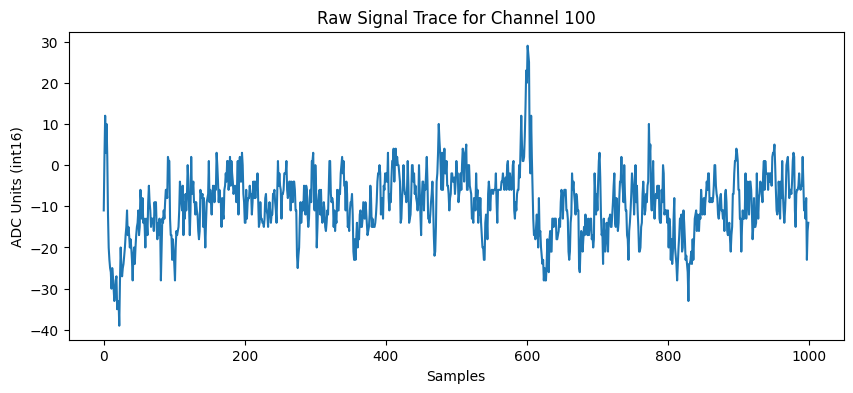

In [8]:
import matplotlib.pyplot as plt

sample_segment = data[0:1000, :] 

plt.figure(figsize=(10, 4))
channel_no=100
plt.plot(sample_segment[:, channel_no])
plt.title(f"Raw Signal Trace for Channel {channel_no}")
plt.xlabel("Samples")
plt.ylabel("ADC Units (int16)")
plt.show()

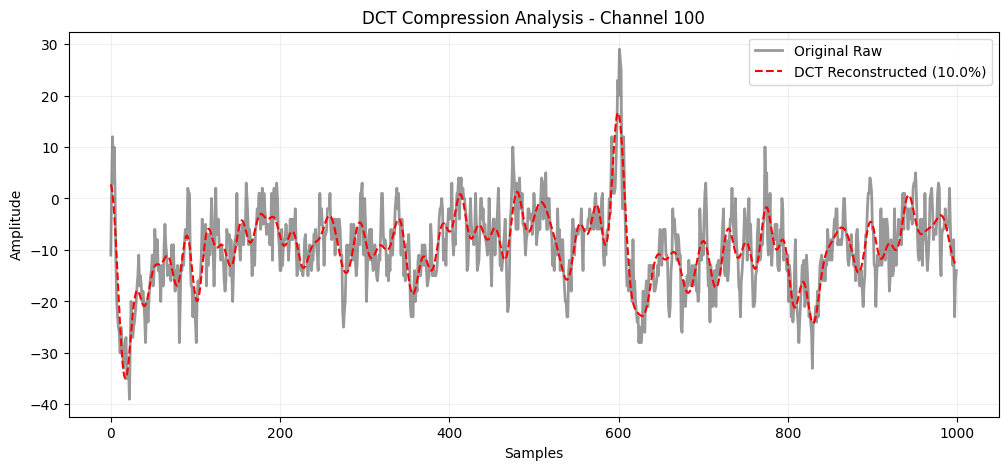

Oringinal sample number: 1000
DCT Sample Number: 100


In [9]:
channel_no=100
raw_signal = data[0:1000, channel_no].astype(np.float32)

keep_ratio = 0.1
reconstructed, coeffs = compress_signal_dct(raw_signal, keep_ratio=keep_ratio)

plt.figure(figsize=(12, 5))

plt.plot(raw_signal, label='Original Raw', color='black', alpha=0.4, linewidth=2)

plt.plot(reconstructed, label=f'DCT Reconstructed ({keep_ratio*100}%)', color='red', linestyle='--')

plt.title(f"DCT Compression Analysis - Channel {channel_no}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Oringinal sample number: {len(raw_signal)}")
print(f"DCT Sample Number: {int(len(raw_signal) * keep_ratio)}")

In [10]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_compression_interactive(channel_no, keep_ratio, sample_range):
    start, end = sample_range
    raw_signal = data[start:end, channel_no].astype(np.float32)
    
    reconstructed, _ = compress_signal_dct(raw_signal, keep_ratio=keep_ratio)
    
    plt.figure(figsize=(12, 5))
    plt.plot(raw_signal, label='Original Raw', color='black', alpha=0.4, linewidth=2)
    plt.plot(reconstructed, label=f'DCT Reconstructed ({keep_ratio*100:.1f}%)', 
             color='red', linestyle='--')
    
    plt.title(f"Interactive DCT Compression - Channel {channel_no}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    
    print(f"Current sample number:  {len(raw_signal)}")
    print(f"Para remaining: {int(len(raw_signal) * keep_ratio)}")
    print(f"Compression Ratio(1/keep_ratio): {1/keep_ratio:.1f}x")

interact(
    plot_compression_interactive, 
    channel_no = widgets.IntText(value=100, description='Channel:'),
    keep_ratio = widgets.FloatSlider(value=0.1, min=0.001, max=1.0, step=0.01, 
                                     description='Keep Ratio:', continuous_update=False),
    sample_range = widgets.IntRangeSlider(value=[0, 1000], min=0, max=20000, step=100,
                                          description='Time Range:', continuous_update=False)
);

interactive(children=(IntText(value=100, description='Channel:'), FloatSlider(value=0.1, continuous_update=Fal…

In [11]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np

#interact modules initial
cluster_input = widgets.IntText(value=0, description='Cluster ID:')
keep_ratio_slider = widgets.FloatSlider(value=0.1, min=0.00, max=1.00, step=0.01, description='Keep Ratio:', continuous_update=False)
spike_no_slider = widgets.IntSlider(value=0, min=0, max=100, description='Spike No.', continuous_update=False)

def plot_waveforms_stack_compression(cluster_id, keep_ratio, spike_no):
    unit_spike_times = st[clu == cluster_id]
    if len(unit_spike_times) == 0:
        print(f"Cluster {cluster_id} has no spikes.")
        return
    total_spikes = len(unit_spike_times)
    print(f"The total spike number for this neuron is {total_spikes}.")
    spike_no_slider.max = total_spikes - 1
    
    idx = min(spike_no, total_spikes - 1)
    center_sample = int(unit_spike_times[idx])
    
    best_ch = chan_best[cluster_id]
    ch_range = 10 # +-10 channels near the best channel
    start_ch = max(0, best_ch - ch_range)
    end_ch = min(384, best_ch + ch_range)
    channels_to_plot = range(start_ch, end_ch + 1)

    # time window
    window = 60 
    start_t = max(0, center_sample - window)
    end_t = min(data.shape[0], center_sample + window)
    
    plt.figure(figsize=(14, 7))
    
    for ch in channels_to_plot:
        raw_ch = data[start_t:end_t, ch].astype(np.float32)
        
        # optimized
        recon_ch, _ = compress_signal_dct(raw_ch, keep_ratio=keep_ratio)
        
        alpha = 1.0 if ch == best_ch else 0.15
        color = 'red' if ch == best_ch else 'gray'
        lw = 2.5 if ch == best_ch else 0.8
        
        if ch == best_ch:
            plt.plot(raw_ch, color='black', alpha=0.5, label='Original (Best Ch)')
            plt.plot(recon_ch, color='red', linestyle='--', linewidth=lw, label=f'Recon (Best Ch, {keep_ratio*100:.1f}%)')
        else:
            plt.plot(raw_ch, color='gray', alpha=alpha, linewidth=lw)
            plt.plot(recon_ch, color='red', alpha=alpha/2, linestyle='--', linewidth=lw)

    plt.title(f"Neuron No. {cluster_id} (Best Ch: {best_ch}) - Spike #{idx}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.1)
    plt.show()
    
    print(f"Showing channels: {start_ch} to {end_ch}")

interact(plot_waveforms_stack_compression, 
         cluster_id=cluster_input, 
         keep_ratio=keep_ratio_slider, 
         spike_no=spike_no_slider);

interactive(children=(IntText(value=0, description='Cluster ID:'), FloatSlider(value=0.1, continuous_update=Fa…

| Original | Original |
| :---: | :---: |
| 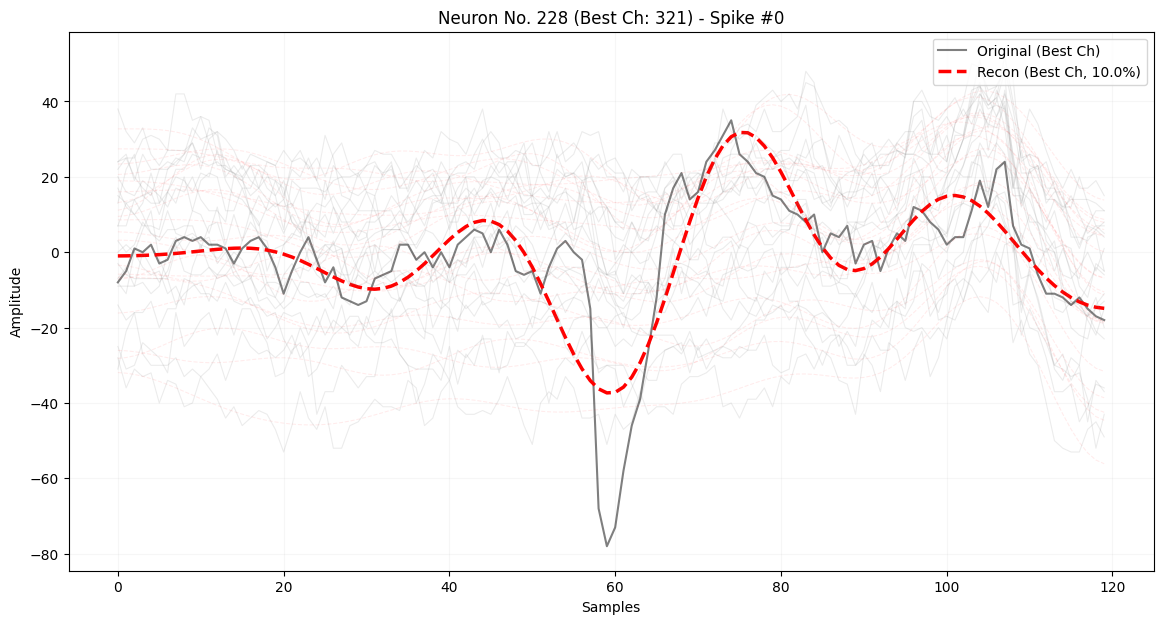 | 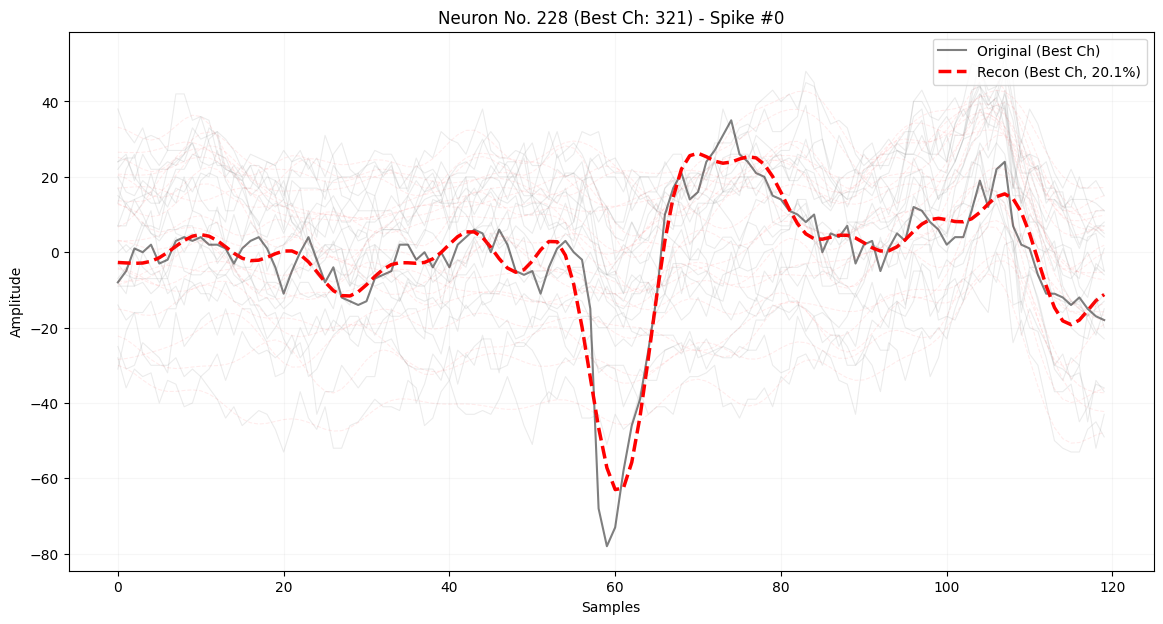 |
| 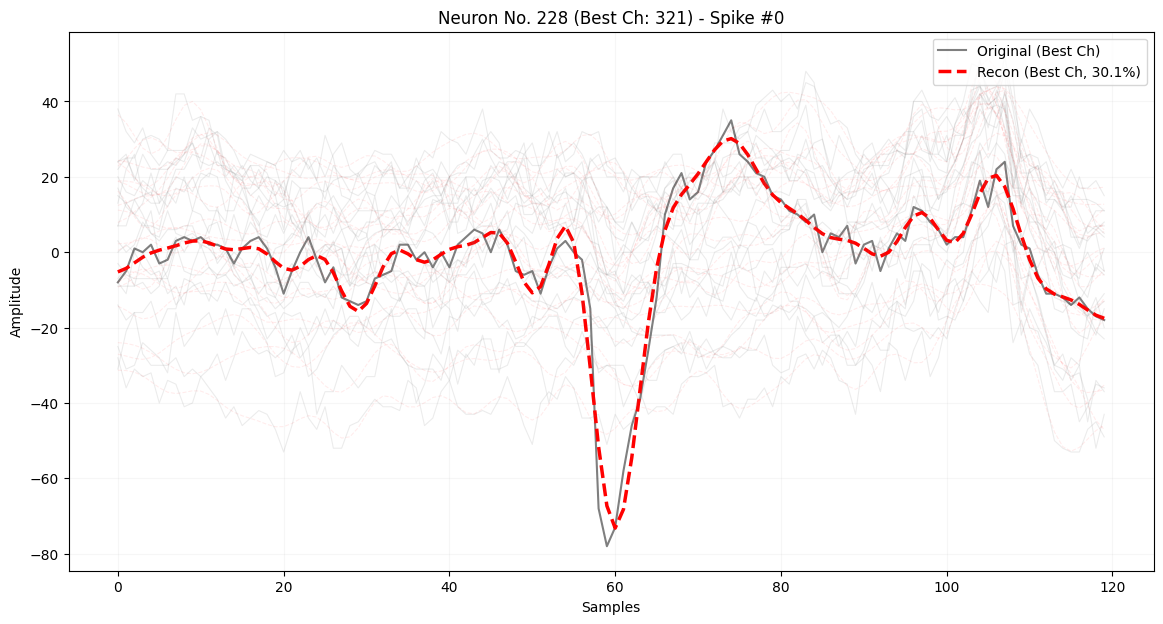 | 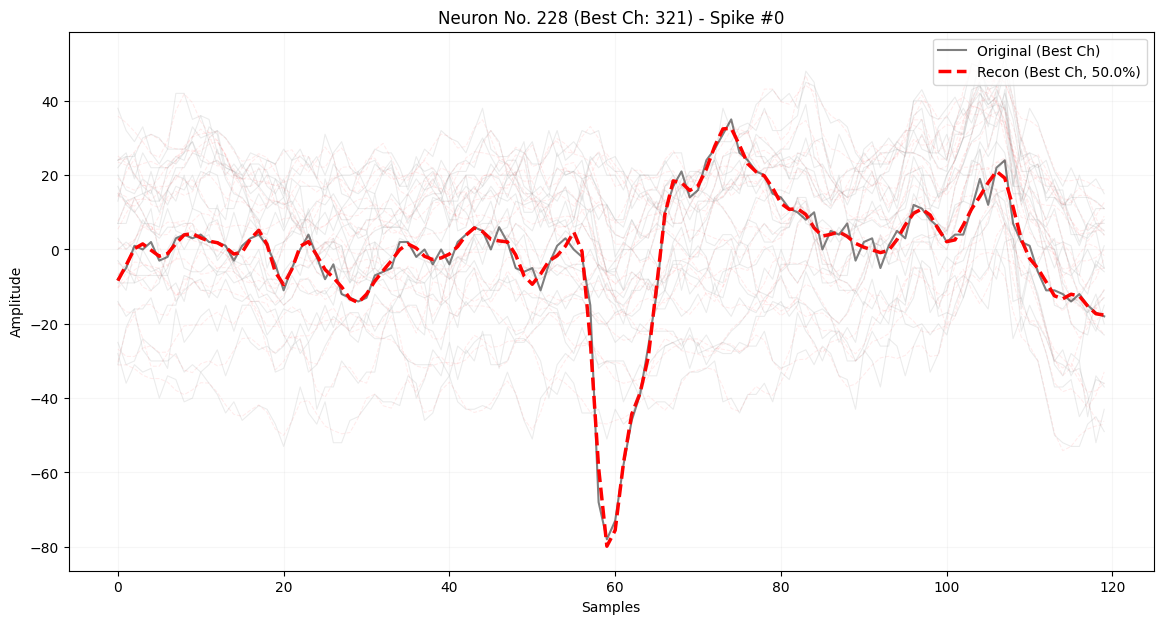 | 
| 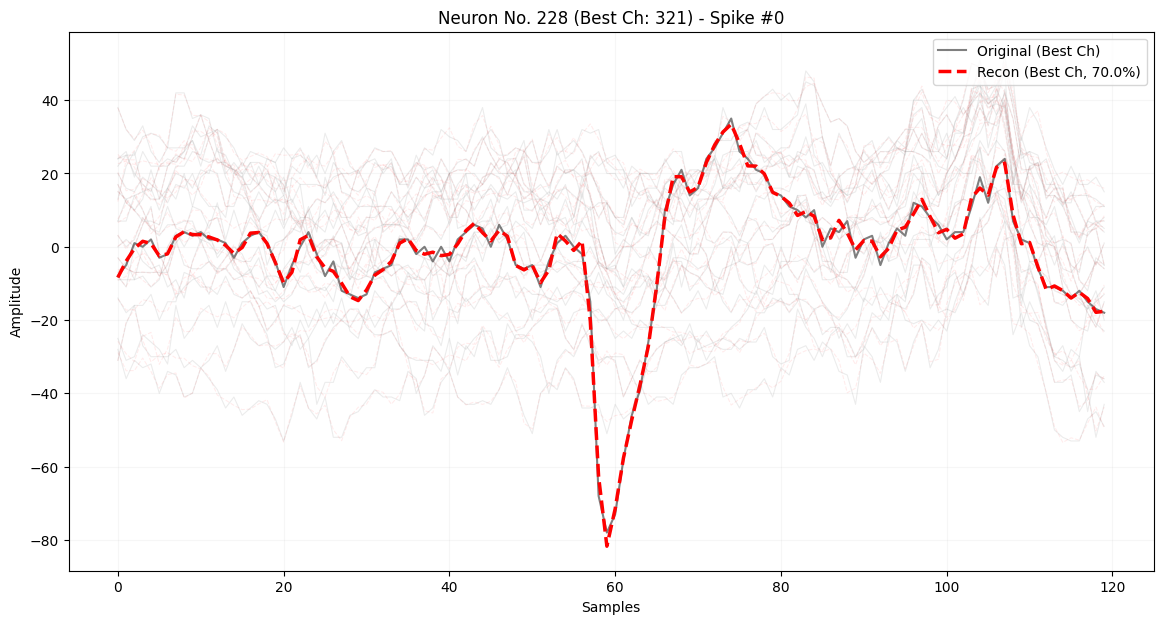 |  |

## 3.Pre-process
### Bandpass filtering, Whitening and Detection
> The incoming signals contain unwanted local field potentials at the lower frequencies (<100-300 Hz) and high frequency noise (>3-6 kHz) .
> 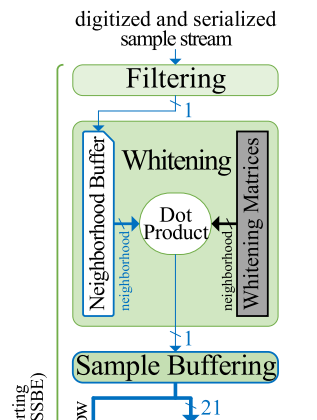

In [12]:
# 2026-5-15
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

In [16]:
butter?

Signature: butter(N, Wn, btype='low', analog=False, output='ba', fs=None)
Docstring:
Butterworth digital and analog filter design.

Design an Nth-order digital or analog Butterworth filter and return
the filter coefficients.

Parameters
----------
N : int
    The order of the filter. For 'bandpass' and 'bandstop' filters,
    the resulting order of the final second-order sections ('sos')
    matrix is ``2*N``, with `N` the number of biquad sections
    of the desired system.
Wn : array_like
    The critical frequency or frequencies. For lowpass and highpass
    filters, Wn is a scalar; for bandpass and bandstop filters,
    Wn is a length-2 sequence.
    
    For a Butterworth filter, this is the point at which the gain
    drops to 1/sqrt(2) that of the passband (the "-3 dB point").
    
    For digital filters, if `fs` is not specified, `Wn` units are
    normalized from 0 to 1, where 1 is the Nyquist frequency (`Wn` is
    thus in half cycles / sample and defined as 2*critical frequ

In [17]:
sosfiltfilt?

Signature: sosfiltfilt(sos, x, axis=-1, padtype='odd', padlen=None)
Docstring:
A forward-backward digital filter using cascaded second-order sections.

See `filtfilt` for more complete information about this method.

Parameters
----------
sos : array_like
    Array of second-order filter coefficients, must have shape
    ``(n_sections, 6)``. Each row corresponds to a second-order
    section, with the first three columns providing the numerator
    coefficients and the last three providing the denominator
    coefficients.
x : array_like
    The array of data to be filtered.
axis : int, optional
    The axis of `x` to which the filter is applied.
    Default is -1.
padtype : str or None, optional
    Must be 'odd', 'even', 'constant', or None.  This determines the
    type of extension to use for the padded signal to which the filter
    is applied.  If `padtype` is None, no padding is used.  The default
    is 'odd'.
padlen : int or None, optional
    The number of elements by which t

In [13]:
def Bandpass_filter(data, lowcut=300, highcut=6000, fs=30000, order=3):
    print("Bandpass filtering is on going...")
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    filtered_data = sosfiltfilt(sos, data, axis=0) 
    return filtered_data

We will use Zero-Phase Component Analysis Whitening method. There is no Phase Shift after whitening. （没有产生相位移动，即零相位）
$$W_{ZCA} = U (S + \epsilon I)^{-\frac{1}{2}} U^T$$

In [14]:
def spatial_whitening(filtered_data):
    """Zero Phase Component Analysis"""
    print("Channel Whitening is on going...")
    
    cov = np.cov(filtered_data, rowvar=False) # (Shape: 385 x 385) rowvar=False: Each column is a channel
    
    # SVD
    U, S, V = np.linalg.svd(cov)
    epsilon = 1e-6 # ε, Regularization term, eliminate divided by 0.
    
    whitening_matrix = dot_matrix = (U / np.sqrt(S + epsilon)) @ U.T  # @ is for Matrix Multiplication.
    print(f"The whitening_matrix is {whitening_matrix}.")
    
    whitened_data = filtered_data @ whitening_matrix.T
    return whitened_data

In the classic Quiroga method, the spike detection threshold for each channel is automatically calculated using the following formulas:

$$\text{Threshold} = k \cdot \sigma_n$$

$$\sigma_n = \text{median} \left( \frac{|x(t)|}{0.6745} \right)$$

### Parameter Descriptions:
*   $x(t)$: The filtered (and whitened) continuous single-channel voltage signal.
*   $k$: The threshold coefficient (typically set to a constant value between $4$ and $5$; in the code, `thresh_num_sigma=4.0` is used).
*   $\sigma_n$: The automatically estimated standard deviation of the pure background noise.
*   $0.6745$: A mathematical constant derived from the Gaussian (normal) distribution ($1 / \Phi^{-1}(0.75) \approx 0.6745$), used to map the median of the absolute values to the true standard deviation of the background noise.

In [15]:
def detect_spikes(whitened_data, channel_no, thresh_num_sigma=4.0): # thresh_num_sigma=4.5 is too large.
    signal = whitened_data[:, channel_no]
    
    sigma_n = np.median(np.abs(signal)) / 0.6745
    threshold = thresh_num_sigma * sigma_n
    
    # Spike typically jumps downwards (negatively).
    # Find the point when falling below the negative threshold
    spike_indices = np.where(signal < -threshold)[0] #[0] converts tuple to array.
    
    # For real neurons, the electrical pathways close within 1 ms after a discharge, making it absolutely physically impossible for them to spike again.
    clean_spike_indices = []
    if len(spike_indices) > 0:
        last_idx = spike_indices[0] # Set the first one as reference, clean the repeated ones.
        clean_spike_indices.append(last_idx)
        for idx in spike_indices[1:]:
            if idx - last_idx > 30:  # 30 samples ≈ 1ms
                clean_spike_indices.append(idx)
            last_idx = idx
            
    return np.array(clean_spike_indices), -threshold

In [ ]:
# Pre-process workflow for a certain neuron.
filtered_data = Bandpass_filter(data)

whitened_data = spatial_whitening(filtered_data)

channel_to_test = 100
spike_locs, thresh_val = detect_spikes(whitened_data, channel_no=channel_to_test)

print(f"For channel no. {channel_to_test} , got  {len(spike_locs)} Spike after pre-process.")

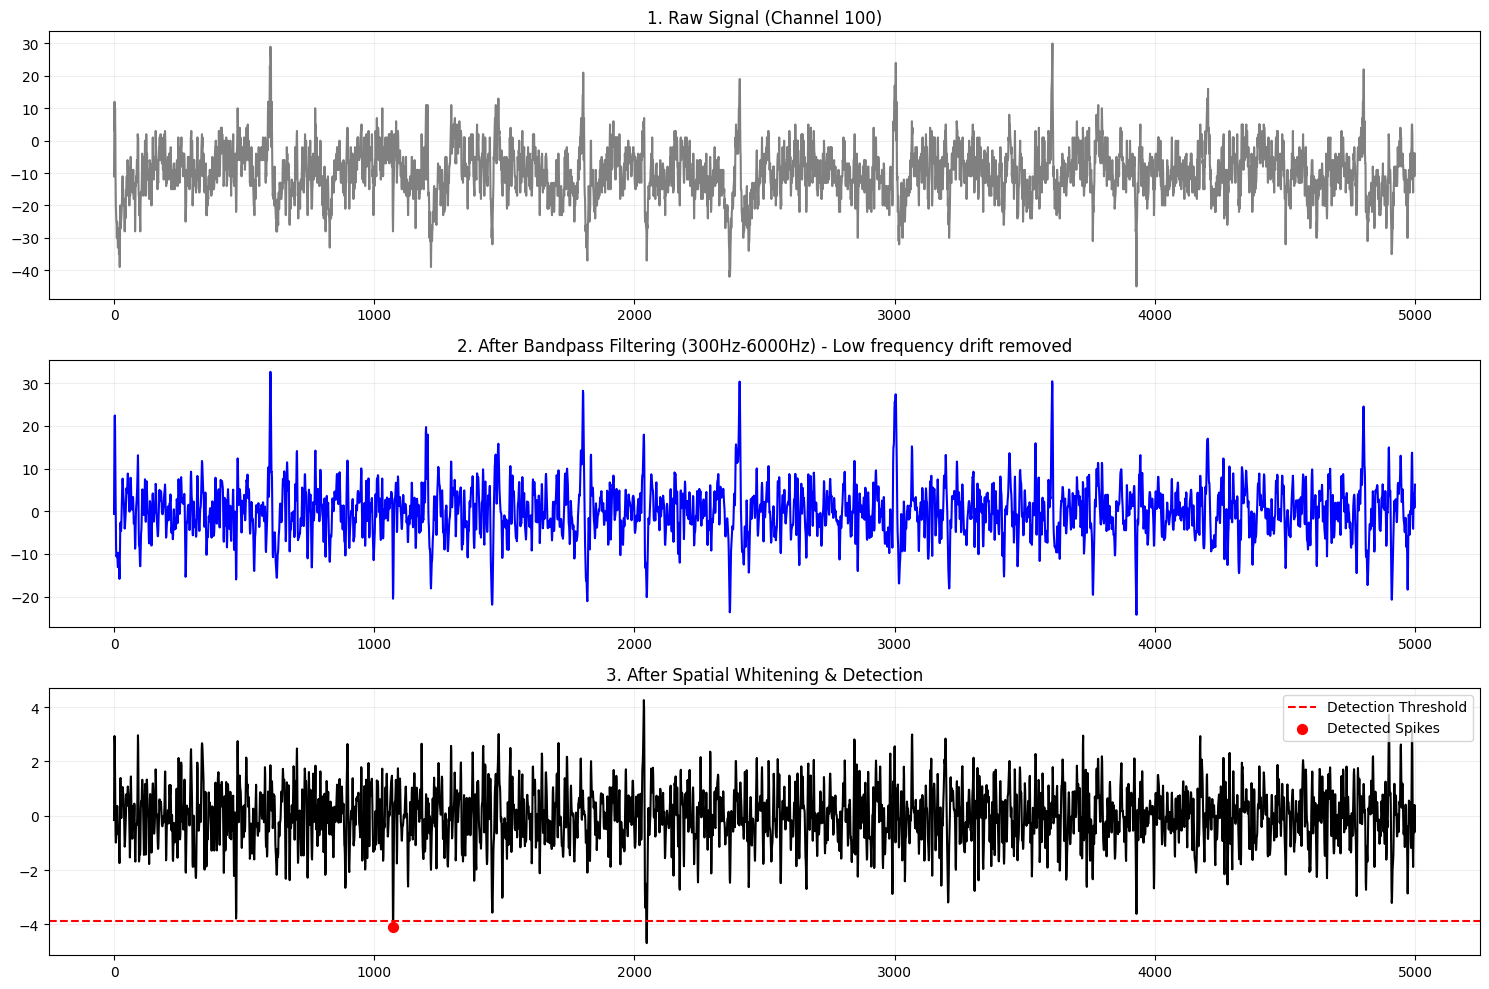

In [30]:
# get first 5000 as an example.
view_win = slice(0, 5000)

plt.figure(figsize=(15, 10))

# original
plt.subplot(3, 1, 1)
plt.plot(data[view_win, channel_to_test], color='gray')
plt.title(f"1. Raw Signal (Channel {channel_to_test})")
plt.grid(True, alpha=0.2)

# after filter
plt.subplot(3, 1, 2)
plt.plot(filtered_data[view_win, channel_to_test], color='blue')
plt.title("2. After Bandpass Filtering (300Hz-6000Hz) - Low frequency drift removed")
plt.grid(True, alpha=0.2)

# after whitening and spike detection
plt.subplot(3, 1, 3)
plt.plot(whitened_data[view_win, channel_to_test], color='black')
# threhold
plt.axhline(y=thresh_val, color='red', linestyle='--', label=f'Detection Threshold')
# detected Spike
visible_spikes = spike_locs[spike_locs < 2000]
if len(visible_spikes) > 0:
    plt.scatter(visible_spikes, whitened_data[visible_spikes, channel_to_test], color='red', s=50, zorder=5, label='Detected Spikes')

plt.title("3. After Spatial Whitening & Detection")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [31]:
import numpy as np
from scipy.fftpack import dct, idct

window_size = 100  # for eacch Spike
keep_ratio = 0.1   
n_keep = int(window_size * keep_ratio)

compressed_snippets = []
for loc in spike_locs:
    
    start = max(0, loc - window_size // 2)
    end = min(whitened_data.shape[0], start + window_size)
    snippet = whitened_data[start:end, channel_to_test].astype(np.float32)
    
    # DCT
    dct_coeffs = dct(snippet, norm='ortho')
    
    # keep first n paras
    compressed_coeffs = np.zeros_like(dct_coeffs)
    compressed_coeffs[:n_keep] = dct_coeffs[:n_keep]
    
    recon = idct(compressed_coeffs, norm='ortho')
    compressed_snippets.append({
        'original': snippet,
        'reconstructed': recon,
        'loc': loc
    })

print(f"Compressed with {len(compressed_snippets)} Spikes in total.")

Compressed with 349 Spikes in total.


In [40]:
spike_slider = widgets.IntSlider(min=0, max=len(compressed_snippets)-1, step=1, description='Spike ID:', continuous_update=False)
spike_input = widgets.IntText(description='Spike ID(Input):', layout=widgets.Layout(width='150px'))
ratio_slider = widgets.FloatSlider(value=0.1, min=0.00, max=1.0, step=0.01, description='Keep Ratio:', continuous_update=False)
neuron_input = widgets.IntText(value=100, description='Neuron No:', layout=widgets.Layout(width='150px'))

widgets.jslink((spike_slider, 'value'), (spike_input, 'value'))

def plot_compressed_explorer(spike_idx, keep_ratio, neuron_no):
    if not compressed_snippets:
        print("Error: No snippets found.")
        return
    
    data_item = compressed_snippets[spike_idx]
    original = data_item['original']
    
    n_keep = int(len(original) * keep_ratio)
    dct_coeffs = dct(original, norm='ortho')
    compressed_coeffs = np.zeros_like(dct_coeffs)
    compressed_coeffs[:n_keep] = dct_coeffs[:n_keep]
    reconstructed = idct(compressed_coeffs, norm='ortho')
    
    plt.figure(figsize=(12, 5))
    plt.plot(original, color='black', alpha=0.3, label=f'Whitened (Ch {neuron_no})')
    plt.plot(reconstructed, color='red', linewidth=2, label=f'DCT Recon ({keep_ratio*100:.1f}%)')
    
    plt.title(f"Neuron {neuron_no} - Spike #{spike_idx} - Ratio: {keep_ratio}")
    plt.xlabel("Samples")
    plt.ylabel("Normalized Amp ($\sigma$)")
    plt.axhline(y=-thresh_num_sigma, color='blue', linestyle='--', alpha=0.2, label='Threshold')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.1)
    plt.ylim(-8, 6)
    plt.show()

ui = widgets.VBox([
    widgets.HBox([spike_slider, spike_input]),
    widgets.HBox([ratio_slider, neuron_input])
])

out = widgets.interactive_output(plot_compressed_explorer, {
    'spike_idx': spike_slider, 
    'keep_ratio': ratio_slider, 
    'neuron_no': neuron_input
})

display(ui, out)

Output()

| After pre-process | After pre-process|
| --- | --- |
| 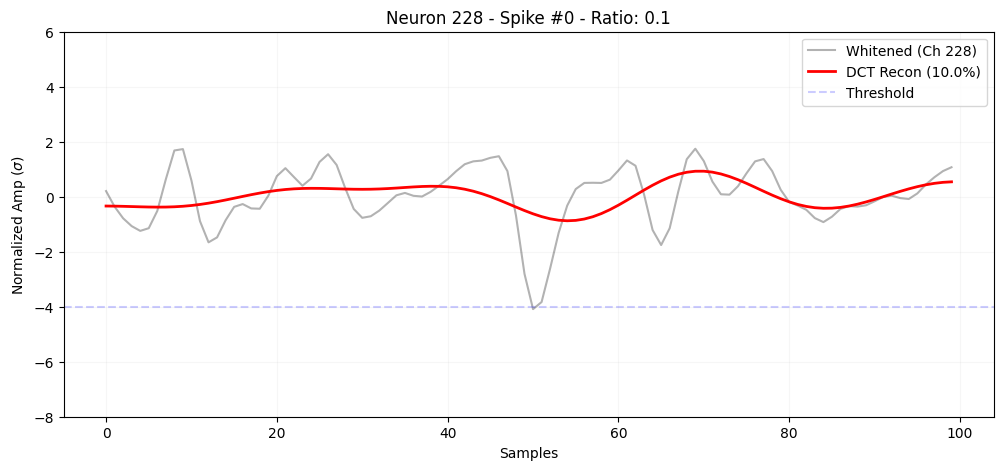 |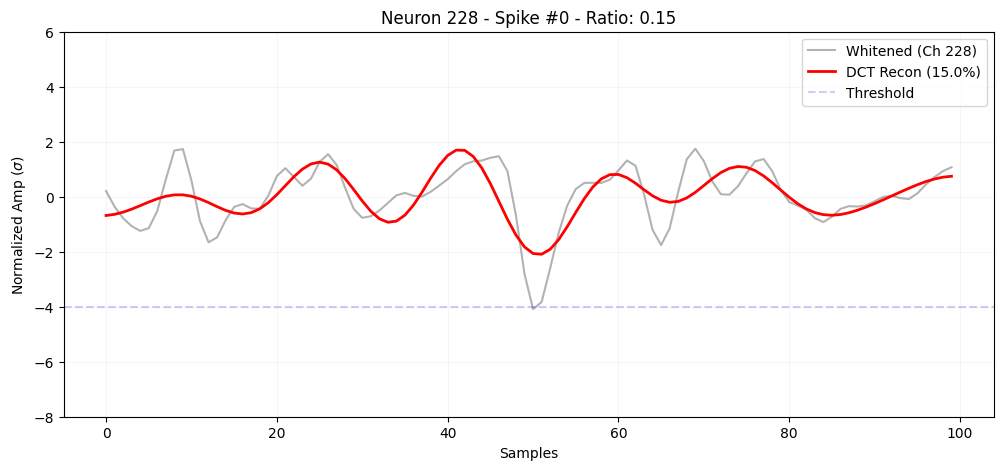|
|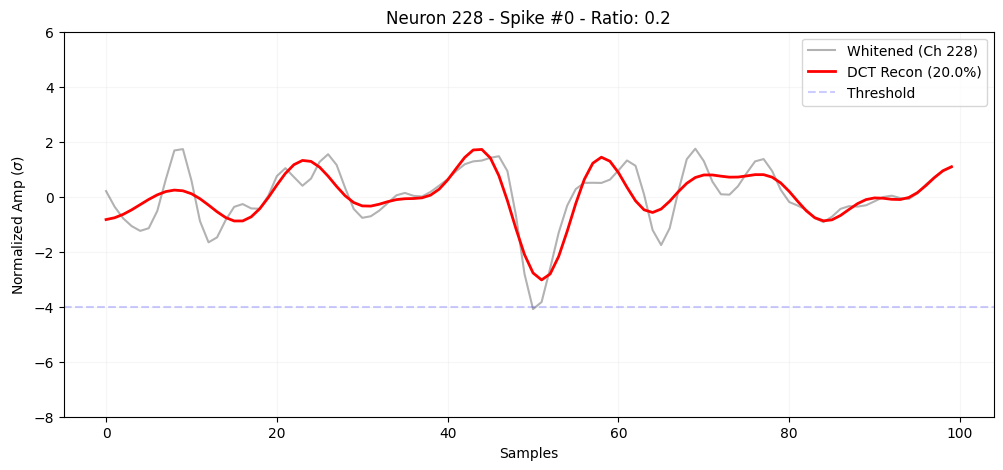 | 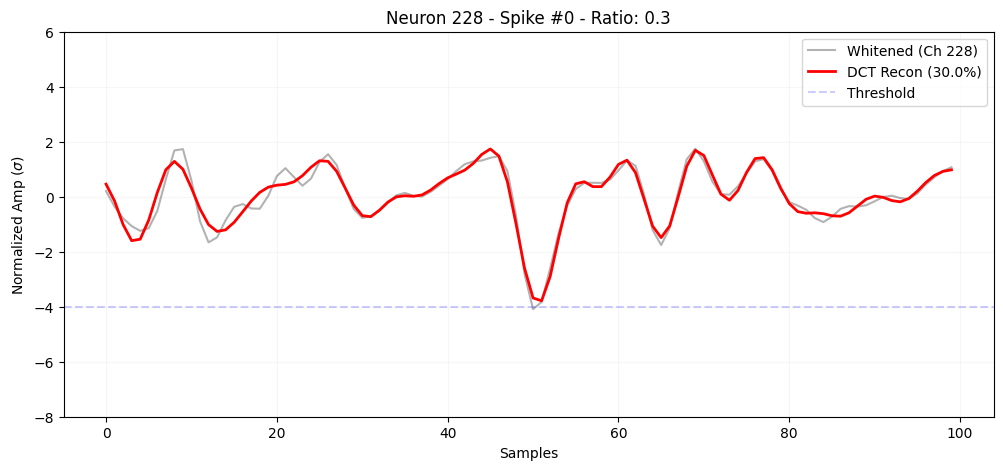 |

In [38]:
# Save the data after whitening
np.save('whitened_data.npy', whitened_data)
print("Saved.")
# whitened_data = np.load('whitened_data.npy')
# print(f"{whitened_data.shape},{whitened_data.dtype}")

Saved.


## 4.Comparing the sorting performances under different keep_ratio

In [4]:
# 2026-5-16
whitened_data = np.load('whitened_data.npy')

In [5]:
baseline_res = {
    'ops': ops,
    'st0': st,
    'templates': templates,
    'xc': ops['xc'],
    'yc': ops['yc'],
    'd_min': ops.get('d_min'),
    'd_max': ops.get('d_max'),
    'd_step': ops.get('d_step'),
    'clu': clu
}
np.save('baseline_results.npy', baseline_res)

import os
import kilosort
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
def process_whitened_to_bin(whitened_data, keep_ratio):
    n_samples, n_chan = whitened_data.shape
    output_path = f'whitened_recon_ratio_{keep_ratio:.2f}.bin'
    
    if os.path.exists(output_path):
        expected_size = n_samples * n_chan * 4
        if os.path.getsize(output_path) == expected_size:
            print(f"File {output_path} already exists and is the correct size; skip the compression step.")
            return output_path
        else:
            print(f"The file {output_path} already exists but is corrupted; please restart the compression process...")

    print(f"Creating file: {output_path}...")
    recon_data = np.memmap(output_path, dtype='float32', mode='w+', shape=(n_samples, n_chan))

    print(f" DCT Compressing (ratio={keep_ratio})...")
    for ch in range(n_chan):
        ch_signal = whitened_data[:, ch]
        dct_coeffs = dct(ch_signal, norm='ortho')
        
        n_keep = int(n_samples * keep_ratio)
        compressed_coeffs = np.zeros(n_samples, dtype='float32')
        compressed_coeffs[:n_keep] = dct_coeffs[:n_keep]
        
        recon_data[:, ch] = idct(compressed_coeffs, norm='ortho')
        
        if ch % 100 == 0:
            print(f"Finished processing {ch}/{n_chan} .")

    recon_data.flush()
    del recon_data
    print(f"Compression completed: {output_path}")
    return output_path

In [52]:
def process_whitened_to_kilo(bin_file, ratio, baseline_res, whitened_data_shape, ops):
    """
    Directly reads Kilosort whitened binary files for sliding window matching and supports local .npy cache detection and skipping.
    """
    import numpy as np
    from scipy.signal import find_peaks
    import os
    from pathlib import Path

    bin_path = Path(bin_file)
    cache_filename = f"matched_results_ratio_{ratio:.2f}.npy"
    cache_path = bin_path.parent / cache_filename

    if cache_path.exists():
        print(f"--> Local cache found: {cache_path.name}")
        print(f"--> Loading cached results and skipping template matching for ratio={ratio}...")
        try:
            loaded_data = np.load(cache_path, allow_pickle=True).item()
            print(f"✓ Successfully loaded from local cache. Total spikes: {len(loaded_data['st'])}")
            return loaded_data
        except Exception as e:
            print(f"⚠ Failed to load corrupted cache file ({e}). Re-calculating...")

    # 2. 解析基础配置参数（若无缓存则正常执行匹配）
    n_samples, n_channels = whitened_data_shape  
    n_kilosort_channels = 385                    
    fs = ops['fs']
    
    print(f"\n🚀 [Pure NumPy Mode] Running template matching with keep_ratio={ratio}...")
    print(f"🎯 Direct parsing Kilosort binary: {bin_file}")
    
    raw_templates = baseline_res['templates']
    n_templates, n_template_time, n_template_ch = raw_templates.shape
    
    if n_template_ch < n_kilosort_channels:
        pad_width = n_kilosort_channels - n_template_ch
        raw_templates = np.pad(raw_templates, ((0,0), (0,0), (0, pad_width)), mode='constant', constant_values=0)
    else:
        raw_templates = raw_templates[:, :, :n_kilosort_channels]
        
    # 3. 分块读取并滑动匹配二进制文件
    chunk_size = int(fs * 10) 
    file_size_bytes = os.path.getsize(bin_file)
    total_samples_in_file = file_size_bytes // (n_kilosort_channels * 4) 
    
    all_spikes_samples = []
    all_spikes_clusters = []
    all_spikes_amplitudes = []
    
    detect_threshold = 4.0 
    
    with open(bin_file, 'rb') as f:
        for start_sample in range(0, total_samples_in_file, chunk_size):
            end_sample = min(start_sample + chunk_size, total_samples_in_file)
            current_chunk_samples = end_sample - start_sample
            
            if current_chunk_samples < n_template_time:
                break
                
            data_bytes = f.read(current_chunk_samples * n_kilosort_channels * 4)
            chunk_data = np.frombuffer(data_bytes, dtype=np.float32).reshape(current_chunk_samples, n_kilosort_channels)
            
            try:
                num_valid_positions = current_chunk_samples - n_template_time + 1
                scores = np.zeros((num_valid_positions, n_templates), dtype=np.float32)
                
                for t in range(n_templates):
                    template_single = raw_templates[t]
                    best_ch = np.argmax(np.max(np.abs(template_single), axis=0))
                    
                    ch_start = max(0, best_ch - 2)
                    ch_end = min(n_kilosort_channels, best_ch + 3)
                    
                    for ch in range(ch_start, ch_end):
                        scores[:, t] += np.correlate(chunk_data[:, ch], template_single[:, ch], mode='valid')
                
                for t in range(n_templates):
                    score_profile = scores[:, t]
                    mad = np.median(np.abs(score_profile - np.median(score_profile))) / 0.6745
                    thresh = detect_threshold * (mad if mad > 0 else 1.0)
                    
                    peaks, _ = find_peaks(score_profile, height=thresh, distance=int(fs * 0.001)) 
                    
                    if len(peaks) > 0:
                        global_samples = start_sample + peaks + (n_template_time // 2)
                        all_spikes_samples.extend(global_samples)
                        all_spikes_clusters.extend([t] * len(peaks))
                        all_spikes_amplitudes.extend(score_profile[peaks])
                        
            except MemoryError:
                print("⚠ Memory limit warning, skipping current chunk...")
                continue

    if len(all_spikes_samples) == 0:
        print("✗ No spikes detected under pure NumPy mode.")
        return None
        
    # 4. 汇总并排序结果
    st_matrix = np.column_stack([
        np.array(all_spikes_samples, dtype=np.int64),
        np.array(all_spikes_clusters, dtype=np.int32),
        np.array(all_spikes_amplitudes, dtype=np.float32)
    ])
    
    sort_idx = np.argsort(st_matrix[:, 0])
    st_matrix = st_matrix[sort_idx]
    
    rez_comp = {
        'st': st_matrix,
        'templates': raw_templates,  
        'clu': st_matrix[:, 1].astype(np.int32),
        'keep_ratio': ratio
    }
    
    # Save
    try:
        np.save(cache_path, rez_comp)
        print(f"✓ Results successfully saved to local cache: {cache_path.name}")
    except Exception as e:
        print(f"⚠ Failed to save results to local disk: {e}")
    
    unique_clusters = np.unique(rez_comp['clu'])
    print(f"✓ [Pure NumPy] Matched {len(st_matrix)} spikes, {len(unique_clusters)} clusters")
    return rez_comp

In [14]:
import spikeinterface as si
import spikeinterface.comparison as sc
import numpy as np
from spikeinterface.core import NumpySorting

def create_sorting_from_rez(rez, fs):
    """Convert rez（baseline_res or rez_comp) to SpikeInterface Sorting object"""
    spike_times = rez['st'][:, 0].astype(np.int64)   # sample indices
    spike_labels = rez['clu'].astype(np.int64)
    
    # convert to dict: {unit_id: spike_times_array}
    unit_dict = {}
    unique_units = np.unique(spike_labels)
    for u in unique_units:
        unit_dict[int(u)] = spike_times[spike_labels == u]
    
    sorting = NumpySorting.from_unit_dict(unit_dict, sampling_frequency=fs)
    return sorting

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

def evaluate_pure_numpy(baseline_res, comp_res, fs, delta_time_ms=0.4):
    """
    【纯独享评估方案】完全不使用 SpikeInterface
    利用纯 NumPy 和 SciPy 计算 Accuracy, Recall, Precision 并绘制一致性矩阵。
    """
    if comp_res is None:
        print("\n[Warning] Evaluation skipped because comp_res is None (No spikes detected).")
        return None
        
    keep_ratio = comp_res.get('keep_ratio', 'N/A')
    print(f"\n==================================================")
    print(f"📊 [Pure NumPy Evaluation] Evaluating keep_ratio = {keep_ratio}")
    print(f"==================================================")
    
    # 1. 提取脉冲时间戳 (单位: sample indices) 和 标签
    st_gt = baseline_res['st'][:, 0].astype(np.int64)
    clu_gt = baseline_res['clu'].astype(np.int32)
    
    st_test = comp_res['st'][:, 0].astype(np.int64)
    clu_test = comp_res['clu'].astype(np.int32)
    
    # 转换为采样点容忍窗口
    delta_samples = int((delta_time_ms / 1000.0) * fs)
    
    unique_gt = np.unique(clu_gt)
    unique_test = np.unique(clu_test)
    
    # 2. 初始化协议/一致性矩阵 (Agreement Matrix)
    # 纵轴代表 Ground Truth (Baseline) 聚类，横轴代表被测试的聚类
    agreement_matrix = np.zeros((len(unique_gt), len(unique_test)), dtype=np.float32)
    
    print("Calculating matching matrix between clusters...")
    # 建立映射索引字典
    gt_idx_map = {id: i for i, id in enumerate(unique_gt)}
    test_idx_map = {id: i for i, id in enumerate(unique_test)}
    
    # 遍历计算两两神经元之间的匹配度 (Jaccard Index / Accuracy)
    for gt_id in unique_gt:
        gt_mask = (clu_gt == gt_id)
        times_gt = st_gt[gt_mask]
        n_gt = len(times_gt)
        if n_gt == 0: continue
            
        i = gt_idx_map[gt_id]
        
        for test_id in unique_test:
            test_mask = (clu_test == test_id)
            times_test = st_test[test_mask]
            n_test = len(times_test)
            if n_test == 0: continue
                
            j = test_idx_map[test_id]
            
            # 使用 searchsorted 快速寻找在时间容忍窗口内的真正匹配脉冲数 (True Positives)
            # 寻找 times_test 中每一个脉冲在 times_gt 里的最近邻
            idx = np.searchsorted(times_gt, times_test)
            
            # 边界修正
            idx_left = np.clip(idx - 1, 0, n_gt - 1)
            idx_right = np.clip(idx, 0, n_gt - 1)
            
            diff_left = np.abs(times_test - times_gt[idx_left])
            diff_right = np.abs(times_test - times_gt[idx_right])
            min_diff = np.minimum(diff_left, diff_right)
            
            # 计算符合时间窗的 True Positives
            tp = np.sum(min_diff <= delta_samples)
            
            # 计算 Accuracy (Jaccard 系数) = TP / (n_gt + n_test - TP)
            if tp > 0:
                accuracy = tp / (n_gt + n_test - tp)
                agreement_matrix[i, j] = accuracy

    # 3. 运行匈牙利算法 (Hungarian Algorithm) 进行最优 1-to-1 配对
    # 为了寻找最大匹配，我们将矩阵取负数
    row_ind, col_ind = linear_sum_assignment(-agreement_matrix)
    
    # 4. 提取统计指标
    print("\n=== Performance Metrics (Top 10 Paired Units) ===")
    print(f"{'GT_Unit':<10}{'Test_Unit':<10}{'Accuracy':<10}{'Recall':<10}{'Precision':<10}")
    print("-" * 55)
    
    well_detected_count = 0
    perf_summary = []
    
    for r, c in zip(row_ind, col_ind):
        acc = agreement_matrix[r, c]
        if acc == 0: continue  # 未匹配成功
            
        gt_id = unique_gt[r]
        test_id = unique_test[c]
        
        n_gt = np.sum(clu_gt == gt_id)
        n_test = np.sum(clu_test == test_id)
        
        # 反推 TP
        # acc = tp / (n_gt + n_test - tp) -> tp = acc * (n_gt + n_test) / (1 + acc)
        tp = (acc * (n_gt + n_test)) / (1.0 + acc)
        
        recall = tp / n_gt if n_gt > 0 else 0
        precision = tp / n_test if n_test > 0 else 0
        
        if acc >= 0.8:
            well_detected_count += 1
            
        perf_summary.append({
            'gt_id': gt_id, 'test_id': test_id,
            'accuracy': acc, 'recall': recall, 'precision': precision
        })
        
        if len(perf_summary) <= 10:  # 先打印前10个看一眼
            print(f"{gt_id:<10}{test_id:<10}{acc:<10.3f}{recall:<10.3f}{precision:<10.3f}")
            
    print("-" * 55)
    print(f"✓ Well-detected units (>80% accuracy): {well_detected_count} / {len(unique_gt)}")
    
    # 5. 纯 matplotlib 画出一致性协议矩阵图 (Agreement Matrix Plot)
    plt.figure(figsize=(10, 8))
    plt.imshow(agreement_matrix, cmap='viridis', aspect='auto', origin='lower')
    plt.colorbar(label='Accuracy (Jaccard Index)')
    plt.xlabel('Tested Cluster Index (Compressed)')
    plt.ylabel('Ground Truth Cluster Index (Baseline)')
    plt.title(f'Agreement Matrix (Pure NumPy Mode, Ratio: {keep_ratio})')
    plt.tight_layout()
    plt.show()
    
    return perf_summary, agreement_matrix

In [54]:
import pandas as pd
from pathlib import Path

ratios = [0.10, 0.20]
results_summary = []
whitened_data_shape = whitened_data.shape

for r in ratios:
    print(f"\n{'='*75}")
    print(f"Processing keep_ratio: {r}")
    print(f"{'='*75}")
    
    # Step 1
    bin_file = process_whitened_to_bin(whitened_data, r)
    if bin_file is None or not Path(bin_file).exists():
        print(f"[ERROR] Skip keep_ratio={r}")
        continue
    
    # Step 2
    rez_comp = process_whitened_to_kilo(bin_file, r, baseline_res, whitened_data_shape, ops)
    if rez_comp is None:
        print(f"[ERROR] Template matching failed for keep_ratio={r}")
        continue
    
    # Step 3
    try:
        perf_summary, agreement_matrix = evaluate_pure_numpy(
            baseline_res, rez_comp, fs=ops['fs'], delta_time_ms=0.4
        )
        
        if perf_summary is None or len(perf_summary) == 0:
            print(f"[ERROR] No matched units for evaluation at keep_ratio={r}")
            continue
            
        # convert to Pandas DataFrame 
        df_perf = pd.DataFrame(perf_summary)
        
        mean_recall = df_perf['recall'].mean()
        mean_accuracy = df_perf['accuracy'].mean()
        
        # The number of high-quality neurons with a statistical precision greater than or equal to 80%.
        well_detected_count = np.sum(df_perf['accuracy'] >= 0.8)
        
        results_summary.append({
            'keep_ratio': r,
            'performance': df_perf,
            'well_detected_count': well_detected_count,
            'recall': mean_recall,
            'accuracy': mean_accuracy
        })
        
        print(f"Evaluation done: Recall: {mean_recall*100:.1f}% | Accuracy: {mean_accuracy*100:.1f}%")
        
    except Exception as e:
        print(f"Pure NumPy evaluation failed: {e}")

print("\n" + "="*75)
print("FINAL RESULT SUMMARY")
print("="*75)
print(f"{'Keep Ratio':<12} | {'Well Det':<10} | {'Mean Recall':<15} | {'Mean Accuracy':<15}")
print("-"*75)

for stats in sorted(results_summary, key=lambda x: x['keep_ratio']):
    print(f"{stats['keep_ratio']*100:>9.1f}%  | "
          f"{stats['well_detected_count']:>8}  | "
          f"{stats['recall']*100:>12.2f}%   | "
          f"{stats['accuracy']*100:>12.2f}%")


Processing keep_ratio: 0.1
File whitened_recon_ratio_0.10.bin already exists and is the correct size; skip the compression step.
--> Local cache found: matched_results_ratio_0.10.npy
--> Loading cached results and skipping template matching for ratio=0.1...
✓ Successfully loaded from local cache. Total spikes: 264753
Pure NumPy evaluation failed: name 'evaluate_pure_numpy' is not defined

Processing keep_ratio: 0.2
File whitened_recon_ratio_0.20.bin already exists and is the correct size; skip the compression step.
--> Local cache found: matched_results_ratio_0.20.npy
--> Loading cached results and skipping template matching for ratio=0.2...
✓ Successfully loaded from local cache. Total spikes: 323221
Pure NumPy evaluation failed: name 'evaluate_pure_numpy' is not defined

FINAL RESULT SUMMARY
Keep Ratio   | Well Det   | Mean Recall     | Mean Accuracy  
---------------------------------------------------------------------------
